# **Automatidata project**
**Course 5 - Regression Analysis: Simplify complex data relationships**

The data consulting firm Automatidata has recently hired you as the newest member of their data analytics team. Their newest client, the NYC Taxi and Limousine Commission (New York City TLC), wants the Automatidata team to build a multiple linear regression model to predict taxi fares using existing data that was collected over the course of a year. The team is getting closer to completing the project, having completed an initial plan of action, initial Python coding work, EDA, and A/B testing.

The Automatidata team has reviewed the results of the A/B testing. Now it’s time to work on predicting the taxi fare amounts. You’ve impressed your Automatidata colleagues with your hard work and attention to detail. The data team believes that you are ready to build the regression model and update the client New York City TLC about your progress.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# Course 5 End-of-course project: Build a multiple linear regression model

In this activity, you will build a multiple linear regression model. As you've learned, multiple linear regression helps you estimate the linear relationship between one continuous dependent variable and two or more independent variables. For data science professionals, this is a useful skill because it allows you to consider more than one variable against the variable you're measuring against. This opens the door for much more thorough and flexible analysis to be completed. 

Completing this activity will help you practice planning out and buidling a multiple linear regression model based on a specific business need. The structure of this activity is designed to emulate the proposals you will likely be assigned in your career as a data professional. Completing this activity will help prepare you for those career moments.
<br/>

**The purpose** of this project is to demostrate knowledge of EDA and a multiple linear regression model

**The goal** is to build a multiple linear regression model and evaluate the model
<br/>
*This activity has three parts:*

**Part 1:** EDA & Checking Model Assumptions
* What are some purposes of EDA before constructing a multiple linear regression model?

**Part 2:** Model Building and evaluation
* What resources do you find yourself using as you complete this stage?

**Part 3:** Interpreting Model Results

* What key insights emerged from your model(s)?

* What business recommendations do you propose based on the models built?

# Build a multiple linear regression model

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**


Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## PACE: **Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.


### Task 1. Imports and loading
Import the packages that you've learned are needed for building linear regression models.

In [1]:
# --- Packages for numerics and dataframes ---
import numpy as np
import pandas as pd

# --- Packages for visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Packages for date conversions and calculating trip durations ---
from datetime import datetime

# --- Packages for model building and evaluation (OLS, MLR, etc.) ---
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics


**Note:** `Pandas` is used to load the NYC TLC dataset. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# Load dataset into dataframe 
df0=pd.read_csv("2017_Yellow_Taxi_Trip_Data.csv") 

<img src="images/Analyze.png" width="100" height="100" align=left>

## PACE: **Analyze**

In this stage, consider the following question where applicable to complete your code response:

* What are some purposes of EDA before constructing a multiple linear regression model?


Exploratory Data Analysis (EDA) is an essential step before building a multiple linear regression model. The main purposes of EDA include:

Understanding the structure of the dataset: EDA helps identify the types of variables (categorical vs numerical), data ranges, and potential relationships between variables.

Detecting missing or anomalous values: This step allows us to find and address any missing, inconsistent, or extreme values that may affect model performance.

Visualizing relationships between variables: EDA enables us to use scatter plots, histograms, and correlation matrices to explore possible linear relationships and multicollinearity among predictors.

Checking distributions: Understanding the distribution of the dependent variable and independent variables helps in deciding whether transformations or normalizations are needed.

Testing model assumptions: Preliminary checks like linearity, homoscedasticity, and absence of multicollinearity can guide model building and improve performance.

In summary, EDA lays the foundation for building a reliable and interpretable regression model by preparing, cleaning, and exploring the data thoroughly.

### Task 2a. Explore data with EDA

Analyze and discover data, looking for correlations, missing data, outliers, and duplicates.

Start with `.shape` and `.info()`.

In [3]:
# Revisa dimensiones del dataset
print("Shape of the dataset:", df0.shape)

# Información general del dataset
print("\nInfo del dataset:")
df0.info()



Shape of the dataset: (22699, 18)

Info del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  t

Check for missing data and duplicates using `.isna()` and `.drop_duplicates()`.

In [4]:
# Ver cuántos valores faltantes hay por columna
print("Valores nulos por columna:")
print(df0.isna().sum())

# Verificar si hay duplicados
num_duplicates = df0.duplicated().sum()
print(f"\nNúmero de filas duplicadas: {num_duplicates}")


Valores nulos por columna:
Unnamed: 0               0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

Número de filas duplicadas: 0


Use `.describe()`.

In [5]:
# Estadísticas descriptivas para columnas numéricas
df0.describe()



,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


### Task 2b. Convert pickup & dropoff columns to datetime


In [6]:
# Mostrar los primeros valores de pickup y dropoff
print("\nPrimeros valores de las columnas de fecha y hora:")
print(df0[['tpep_pickup_datetime', 'tpep_dropoff_datetime']].head())



Primeros valores de las columnas de fecha y hora:
     tpep_pickup_datetime   tpep_dropoff_datetime
0   03/25/2017 8:55:43 AM   03/25/2017 9:09:47 AM
1   04/11/2017 2:53:28 PM   04/11/2017 3:19:58 PM
2   12/15/2017 7:26:56 AM   12/15/2017 7:34:08 AM
3   05/07/2017 1:17:59 PM   05/07/2017 1:48:14 PM
4  04/15/2017 11:32:20 PM  04/15/2017 11:49:03 PM


In [7]:
# Conversión explícita con formato
df0['tpep_pickup_datetime'] = pd.to_datetime(df0['tpep_pickup_datetime'], format="%m/%d/%Y %I:%M:%S %p")
df0['tpep_dropoff_datetime'] = pd.to_datetime(df0['tpep_dropoff_datetime'], format="%m/%d/%Y %I:%M:%S %p")

# Verificación
print(df0[['tpep_pickup_datetime', 'tpep_dropoff_datetime']].dtypes)


tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
dtype: object


### Task 2c. Create duration column

Create a new column called `duration` that represents the total number of minutes that each taxi ride took.

In [8]:
# Calcular duración del viaje en minutos
df0['duration'] = (df0['tpep_dropoff_datetime'] - df0['tpep_pickup_datetime']).dt.total_seconds() / 60

# Verificar primeras filas de la nueva columna
print(df0[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'duration']].head())


  tpep_pickup_datetime tpep_dropoff_datetime   duration
0  2017-03-25 08:55:43   2017-03-25 09:09:47  14.066667
1  2017-04-11 14:53:28   2017-04-11 15:19:58  26.500000
2  2017-12-15 07:26:56   2017-12-15 07:34:08   7.200000
3  2017-05-07 13:17:59   2017-05-07 13:48:14  30.250000
4  2017-04-15 23:32:20   2017-04-15 23:49:03  16.716667


### Outliers

Call `df.info()` to inspect the columns and decide which ones to check for outliers.

In [9]:
# Inspeccionar estructura del DataFrame
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[ns]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  object        
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  m

Keeping in mind that many of the features will not be used to fit your model, the most important columns to check for outliers are likely to be:
* `trip_distance`
* `fare_amount`
* `duration`



### Task 2d. Box plots

Plot a box plot for each feature: `trip_distance`, `fare_amount`, `duration`.

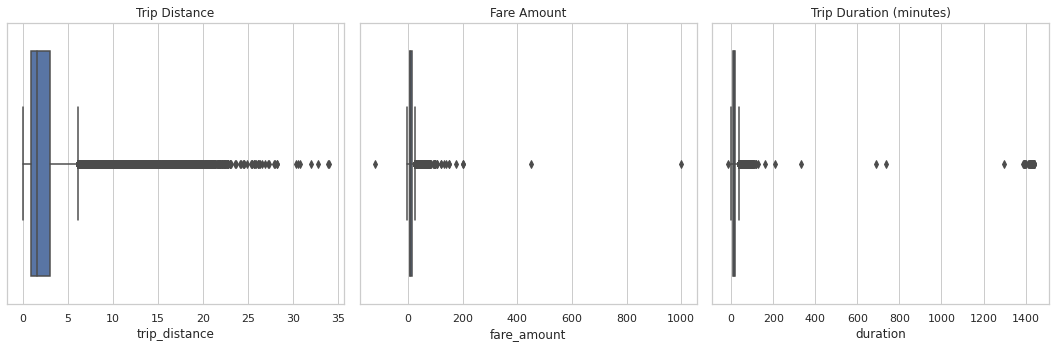

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de gráficos
sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))

# Boxplot: trip_distance
plt.subplot(1, 3, 1)
sns.boxplot(x=df0['trip_distance'])
plt.title('Trip Distance')

# Boxplot: fare_amount
plt.subplot(1, 3, 2)
sns.boxplot(x=df0['fare_amount'])
plt.title('Fare Amount')

# Boxplot: duration
plt.subplot(1, 3, 3)
sns.boxplot(x=df0['duration'])
plt.title('Trip Duration (minutes)')

plt.tight_layout()
plt.show()



**Questions:** 
1. Which variable(s) contains outliers? 

2. Are the values in the `trip_distance` column unbelievable?

3. What about the lower end? Do distances, fares, and durations of 0 (or negative values) make sense?

The box plots reveal that all three variables — trip_distance, fare_amount, and duration — contain outliers. These are indicated by individual points far from the interquartile range, especially on the upper end.

Are the values in the trip_distance column unbelievable?
Yes, some values in trip_distance appear to be unusually high and likely represent data entry errors or edge cases such as airport trips or misrecorded distances. Distances significantly above the typical range (e.g., more than 50 miles) may be worth reviewing or removing.

What about the lower end? Do distances, fares, and durations of 0 (or negative values) make sense?
No, values of 0 or negative for trip_distance, fare_amount, and duration are not realistic in the context of taxi trips. A ride cannot take zero time, cover zero distance, or cost nothing. These entries likely indicate incomplete, incorrect, or faulty records and should be removed or handled before building the regression model.

### Task 2e. Imputations

#### `trip_distance` outliers

You know from the summary statistics that there are trip distances of 0. Are these reflective of erroneous data, or are they very short trips that get rounded down?

To check, sort the column values, eliminate duplicates, and inspect the least 10 values. Are they rounded values or precise values?

In [11]:
# Ver los primeros 10 valores únicos de trip_distance ordenados
sorted_distances = df0['trip_distance'].sort_values().drop_duplicates()
print("Primeros 10 valores únicos en 'trip_distance':")
print(sorted_distances.head(10))



Primeros 10 valores únicos en 'trip_distance':
22026    0.00
5501     0.01
16827    0.02
21088    0.03
13517    0.04
10146    0.05
14373    0.06
922      0.07
22523    0.08
22035    0.09
Name: trip_distance, dtype: float64


The distances are captured with a high degree of precision. However, it might be possible for trips to have distances of zero if a passenger summoned a taxi and then changed their mind. Besides, are there enough zero values in the data to pose a problem?

Calculate the count of rides where the `trip_distance` is zero.

In [12]:
# Contar cuántas filas tienen trip_distance igual a 0
zero_distance_count = (df0['trip_distance'] == 0).sum()
print(f"Número de viajes con trip_distance igual a 0: {zero_distance_count}")


Número de viajes con trip_distance igual a 0: 148


#### `fare_amount` outliers

In [13]:
# Contar cuántos valores de fare_amount son menores o iguales a 0
invalid_fares = df0[df0['fare_amount'] <= 0]
print(f"Número de registros con fare_amount <= 0: {invalid_fares.shape[0]}")

# Mostrar los primeros registros con tarifas inválidas
print("\nEjemplos de registros con fare_amount inválido:")
print(invalid_fares[['fare_amount', 'trip_distance', 'duration']].head())


Número de registros con fare_amount <= 0: 20

Ejemplos de registros con fare_amount inválido:
      fare_amount  trip_distance   duration
314          -2.5           0.12   0.483333
1646         -2.5           0.04   0.616667
4402          0.0           7.06  40.950000
4423         -3.0           0.06   1.333333
5448         -3.5           0.25   2.216667


**Question:** What do you notice about the values in the `fare_amount` column?

Impute values less than $0 with `0`.

In [14]:
# Reemplazar valores negativos de fare_amount con 0
df0.loc[df0['fare_amount'] < 0, 'fare_amount'] = 0

# Verificación rápida
print("Valores menores a 0 después de imputación:", (df0['fare_amount'] < 0).sum())


Valores menores a 0 después de imputación: 0


Now impute the maximum value as `Q3 + (6 * IQR)`.

In [15]:
# Lista de columnas que deseas procesar (por ejemplo, 'fare_amount', 'trip_distance', 'duration')
column_list = ['fare_amount', 'trip_distance', 'duration']
iqr_factor = 6

for column in column_list:
    # Calcular Q1 y Q3
    Q1 = df0[column].quantile(0.25)
    Q3 = df0[column].quantile(0.75)
    
    # Calcular IQR
    IQR = Q3 - Q1
    
    # Calcular el umbral superior
    upper_threshold = Q3 + (iqr_factor * IQR)
    
    # Imputar valores mayores al umbral con el umbral mismo
    df0.loc[df0[column] > upper_threshold, column] = upper_threshold


#### `duration` outliers


In [16]:
# Estadísticas descriptivas para la columna 'duration'
df0['duration'].describe()


count    22699.000000
mean        14.459807
std         11.948480
min        -16.983333
25%          6.650000
50%         11.183333
75%         18.383333
max         88.783333
Name: duration, dtype: float64

The `duration` column has problematic values at both the lower and upper extremities.

* **Low values:** There should be no values that represent negative time. Impute all negative durations with `0`.

* **High values:** Impute high values the same way you imputed the high-end outliers for fares: `Q3 + (6 * IQR)`.

In [17]:
# 1. Imputar valores negativos con 0
df0.loc[df0['duration'] < 0, 'duration'] = 0

In [18]:
# 2. Imputar valores altos: Q3 + (6 * IQR)
Q1_duration = df0['duration'].quantile(0.25)
Q3_duration = df0['duration'].quantile(0.75)
IQR_duration = Q3_duration - Q1_duration
upper_threshold_duration = Q3_duration + (6 * IQR_duration)

# Imputar los valores de 'duration' que son mayores al umbral
df0.loc[df0['duration'] > upper_threshold_duration, 'duration'] = upper_threshold_duration

### Task 3a. Feature engineering

#### Create `mean_distance` column

When deployed, the model will not know the duration of a trip until after the trip occurs, so you cannot train a model that uses this feature. However, you can use the statistics of trips you *do* know to generalize about ones you do not know.

In this step, create a column called `mean_distance` that captures the mean distance for each group of trips that share pickup and dropoff points.

For example, if your data were:

|Trip|Start|End|Distance|
|--: |:---:|:-:|    |
| 1  | A   | B | 1  |
| 2  | C   | D | 2  |
| 3  | A   | B |1.5 |
| 4  | D   | C | 3  |

The results should be:
```
A -> B: 1.25 miles
C -> D: 2 miles
D -> C: 3 miles
```

Notice that C -> D is not the same as D -> C. All trips that share a unique pair of start and end points get grouped and averaged.

Then, a new column `mean_distance` will be added where the value at each row is the average for all trips with those pickup and dropoff locations:

|Trip|Start|End|Distance|mean_distance|
|--: |:---:|:-:|  :--   |:--   |
| 1  | A   | B | 1      | 1.25 |
| 2  | C   | D | 2      | 2    |
| 3  | A   | B |1.5     | 1.25 |
| 4  | D   | C | 3      | 3    |


Begin by creating a helper column called `pickup_dropoff`, which contains the unique combination of pickup and dropoff location IDs for each row.

One way to do this is to convert the pickup and dropoff location IDs to strings and join them, separated by a space. The space is to ensure that, for example, a trip with pickup/dropoff points of 12 & 151 gets encoded differently than a trip with points 121 & 51.

So, the new column would look like this:

|Trip|Start|End|pickup_dropoff|
|--: |:---:|:-:|  :--         |
| 1  | A   | B | 'A B'        |
| 2  | C   | D | 'C D'        |
| 3  | A   | B | 'A B'        |
| 4  | D   | C | 'D C'        |


In [22]:
# Crear la columna pickup_dropoff combinando PULocationID y DOLocationID
df0['pickup_dropoff'] = df0['PULocationID'].astype(str) + ' ' + df0['DOLocationID'].astype(str)

# Verificar las primeras filas para asegurarnos de que la columna se creó correctamente
print(df0[['PULocationID', 'DOLocationID', 'pickup_dropoff']].head())



   PULocationID  DOLocationID pickup_dropoff
0           100           231        100 231
1           186            43         186 43
2           262           236        262 236
3           188            97         188 97
4             4           112          4 112


Now, use a `groupby()` statement to group each row by the new `pickup_dropoff` column, compute the mean, and capture the values only in the `trip_distance` column. Assign the results to a variable named `grouped`.

In [23]:
# Agrupar por la columna 'pickup_dropoff' y calcular la media de 'trip_distance'
grouped = df0.groupby('pickup_dropoff')['trip_distance'].mean()

# Verificar los primeros valores de 'grouped'
print(grouped.head())


pickup_dropoff
1 1         2.433333
10 148     15.480000
100 1      15.480000
100 100     0.253333
100 107     1.180000
Name: trip_distance, dtype: float64


`grouped` is an object of the `DataFrame` class.

1. Convert it to a dictionary using the [`to_dict()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_dict.html) method. Assign the results to a variable called `grouped_dict`. This will result in a dictionary with a key of `trip_distance` whose values are another dictionary. The inner dictionary's keys are pickup/dropoff points and its values are mean distances. This is the information you want.

```
Example:
grouped_dict = {'trip_distance': {'A B': 1.25, 'C D': 2, 'D C': 3}
```

2. Reassign the `grouped_dict` dictionary so it contains only the inner dictionary. In other words, get rid of `trip_distance` as a key, so:

```
Example:
grouped_dict = {'A B': 1.25, 'C D': 2, 'D C': 3}
 ```

In [24]:
# Convertir el objeto 'grouped' a un diccionario
grouped_dict = grouped.to_dict()

# Verificar la estructura del diccionario
print(grouped_dict)
# Eliminar el nivel superior 'trip_distance' y conservar solo el diccionario interno
grouped_dict = grouped_dict

# Verificar el resultado
print(grouped_dict)


{'1 1': 2.433333333333333, '10 148': 15.480000000000002, '100 1': 15.480000000000002, '100 100': 0.25333333333333335, '100 107': 1.18, '100 113': 2.024, '100 114': 1.94, '100 12': 4.55, '100 125': 2.84, '100 13': 4.201666666666667, '100 132': 15.480000000000002, '100 137': 1.299, '100 138': 10.432857142857143, '100 140': 2.746, '100 141': 2.11, '100 142': 1.6958333333333335, '100 143': 1.5825, '100 144': 3.0066666666666664, '100 148': 4.1066666666666665, '100 151': 3.668, '100 152': 4.9, '100 158': 1.938, '100 161': 0.9813888888888889, '100 162': 1.2163636363636363, '100 163': 1.2656, '100 164': 0.841, '100 166': 5.199999999999999, '100 170': 0.8548, '100 177': 12.0, '100 181': 9.34, '100 186': 0.6404761904761904, '100 193': 4.39, '100 198': 9.01, '100 202': 5.3, '100 209': 4.43, '100 211': 2.48, '100 224': 1.9500000000000002, '100 225': 7.5, '100 229': 1.7850000000000001, '100 230': 0.72975, '100 231': 3.5216666666666665, '100 232': 3.8449999999999998, '100 233': 1.2458333333333333, '

1. Create a `mean_distance` column that is a copy of the `pickup_dropoff` helper column.

2. Use the [`map()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html#pandas-series-map) method on the `mean_distance` series. Pass `grouped_dict` as its argument. Reassign the result back to the `mean_distance` series.
</br></br>
When you pass a dictionary to the `Series.map()` method, it will replace the data in the series where that data matches the dictionary's keys. The values that get imputed are the values of the dictionary.

```
Example:
df['mean_distance']
```

|mean_distance |
|  :-:         |
| 'A B'        |
| 'C D'        |
| 'A B'        |
| 'D C'        |
| 'E F'        |

```
grouped_dict = {'A B': 1.25, 'C D': 2, 'D C': 3}
df['mean_distance`] = df['mean_distance'].map(grouped_dict)
df['mean_distance']
```

|mean_distance |
|  :-:         |
| 1.25         |
| 2            |
| 1.25         |
| 3            |
| NaN          |

When used this way, the `map()` `Series` method is very similar to `replace()`, however, note that `map()` will impute `NaN` for any values in the series that do not have a corresponding key in the mapping dictionary, so be careful.

In [25]:
# Crear la columna 'mean_distance' como una copia de la columna 'pickup_dropoff'
df0['mean_distance'] = df0['pickup_dropoff']
# Usar el diccionario 'grouped_dict' para asignar las distancias medias en 'mean_distance'
df0['mean_distance'] = df0['mean_distance'].map(grouped_dict)

# Verificar los primeros valores para asegurarnos de que el mapeo funcionó
print(df0[['pickup_dropoff', 'mean_distance']].head())


  pickup_dropoff  mean_distance
0        100 231       3.521667
1         186 43       3.108889
2        262 236       0.881429
3         188 97       3.700000
4          4 112       4.435000


#### Create `mean_duration` column

Repeat the process used to create the `mean_distance` column to create a `mean_duration` column.

In [27]:
# Crear la columna 'mean_duration' como una copia de 'pickup_dropoff'
df0['mean_duration'] = df0['pickup_dropoff']

# Mapear el diccionario de duración media al 'mean_duration'
df0['mean_duration'] = df0['mean_duration'].map(grouped_duration_dict)

# Verificar los primeros valores para asegurarnos de que el mapeo funcionó
print(df0[['pickup_dropoff', 'mean_duration']].head())


  pickup_dropoff  mean_duration
0        100 231      22.847222
1         186 43      24.470370
2        262 236       7.250000
3         188 97      30.250000
4          4 112      14.616667


#### Create `day` and `month` columns

Create two new columns, `day` (name of day) and `month` (name of month) by extracting the relevant information from the `tpep_pickup_datetime` column.

In [28]:
# Crear la columna 'day' extrayendo el nombre del día de 'tpep_pickup_datetime'
df0['day'] = df0['tpep_pickup_datetime'].dt.day_name()

# Verificar los primeros valores de la columna 'day'
print(df0[['tpep_pickup_datetime', 'day']].head())

# Crear la columna 'month' extrayendo el nombre del mes de 'tpep_pickup_datetime'
df0['month'] = df0['tpep_pickup_datetime'].dt.month_name()

# Verificar los primeros valores de la columna 'month'
print(df0[['tpep_pickup_datetime', 'month']].head())


  tpep_pickup_datetime       day
0  2017-03-25 08:55:43  Saturday
1  2017-04-11 14:53:28   Tuesday
2  2017-12-15 07:26:56    Friday
3  2017-05-07 13:17:59    Sunday
4  2017-04-15 23:32:20  Saturday
  tpep_pickup_datetime     month
0  2017-03-25 08:55:43     March
1  2017-04-11 14:53:28     April
2  2017-12-15 07:26:56  December
3  2017-05-07 13:17:59       May
4  2017-04-15 23:32:20     April


#### Create `rush_hour` column

Define rush hour as:
* Any weekday (not Saturday or Sunday) AND
* Either from 06:00&ndash;10:00 or from 16:00&ndash;20:00

Create a binary `rush_hour` column that contains a 1 if the ride was during rush hour and a 0 if it was not.

In [29]:
# Definir la función 'rush_hourizer' para verificar si el viaje es en hora punta
def rush_hourizer(row):
    # Extraer el día de la semana y la hora del pickup
    day = row['day']
    hour = row['tpep_pickup_datetime'].hour
    
    # Comprobar si es un día laborable y si la hora está dentro del rango de hora punta
    if day not in ['Saturday', 'Sunday'] and (6 <= hour < 10 or 16 <= hour < 20):
        return 1
    else:
        return 0

# Crear la columna 'rush_hour' aplicando la función
df0['rush_hour'] = df0.apply(rush_hourizer, axis=1)

# Imputar 0 si el día es sábado o domingo
df0.loc[df0['day'].isin(['Saturday', 'Sunday']), 'rush_hour'] = 0

# Verificar los primeros valores de la columna 'rush_hour'
print(df0[['tpep_pickup_datetime', 'day', 'rush_hour']].head())


  tpep_pickup_datetime       day  rush_hour
0  2017-03-25 08:55:43  Saturday          0
1  2017-04-11 14:53:28   Tuesday          0
2  2017-12-15 07:26:56    Friday          1
3  2017-05-07 13:17:59    Sunday          0
4  2017-04-15 23:32:20  Saturday          0


In [30]:
# Aplicar la función 'rush_hourizer' a cada fila del DataFrame
df0['rush_hour'] = df0.apply(rush_hourizer, axis=1)

In [31]:
# Verificar los primeros valores de la columna 'rush_hour' para asegurar que la función se aplicó correctamente
print(df0[['tpep_pickup_datetime', 'day', 'rush_hour']].head())

  tpep_pickup_datetime       day  rush_hour
0  2017-03-25 08:55:43  Saturday          0
1  2017-04-11 14:53:28   Tuesday          0
2  2017-12-15 07:26:56    Friday          1
3  2017-05-07 13:17:59    Sunday          0
4  2017-04-15 23:32:20  Saturday          0


### Task 4. Scatter plot

Create a scatterplot to visualize the relationship between `mean_duration` and `fare_amount`.

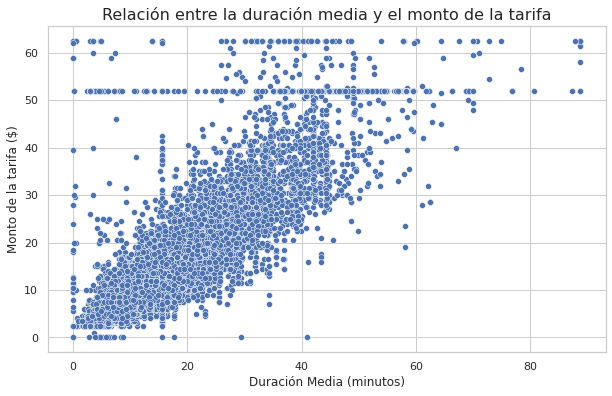

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df0['mean_duration'], y=df0['fare_amount'])

# Añadir títulos y etiquetas
plt.title('Relación entre la duración media y el monto de la tarifa', fontsize=16)
plt.xlabel('Duración Media (minutos)', fontsize=12)
plt.ylabel('Monto de la tarifa ($)', fontsize=12)

# Mostrar el gráfico
plt.show()


The `mean_duration` variable correlates with the target variable. But what are the horizontal lines around fare amounts of 52 dollars and 63 dollars? What are the values and how many are there?

You know what one of the lines represents. 62 dollars and 50 cents is the maximum that was imputed for outliers, so all former outliers will now have fare amounts of \$62.50. What is the other line?

Check the value of the rides in the second horizontal line in the scatter plot.

In [33]:
# Verificar las filas con fare_amount de 52 y 63 dólares
fare_52 = df0[df0['fare_amount'] == 52]
fare_63 = df0[df0['fare_amount'] == 63]

# Mostrar el número de registros para cada tarifa
print(f"Número de registros con fare_amount igual a 52: {fare_52.shape[0]}")
print(f"Número de registros con fare_amount igual a 63: {fare_63.shape[0]}")

# Verificar las primeras filas para observar más detalles
print("\nPrimeros registros con fare_amount = 52:")
print(fare_52.head())

print("\nPrimeros registros con fare_amount = 63:")
print(fare_63.head())


Número de registros con fare_amount igual a 52: 514
Número de registros con fare_amount igual a 63: 0

Primeros registros con fare_amount = 52:
     Unnamed: 0  VendorID tpep_pickup_datetime tpep_dropoff_datetime  \
11     18600059         2  2017-03-05 19:15:30   2017-03-05 19:52:18   
110    47959795         1  2017-06-03 14:24:57   2017-06-03 15:31:48   
161    95729204         2  2017-11-11 20:16:16   2017-11-11 20:17:14   
247   103404868         2  2017-12-06 23:37:08   2017-12-07 00:06:19   
379    80479432         2  2017-09-24 23:45:45   2017-09-25 00:15:14   

     passenger_count  trip_distance  RatecodeID store_and_fwd_flag  \
11                 2          15.48           2                  N   
110                1          15.48           2                  N   
161                1           0.23           2                  N   
247                1          15.48           2                  N   
379                1          15.48           2                  N   

  

Examine the first 30 of these trips.

In [34]:
# Importar pandas
import pandas as pd

# Establecer pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Mostrar las primeras 30 filas de los viajes con fare_amount igual a 52 o 63 dólares
print("Primeros 30 registros con fare_amount igual a 52:")
print(fare_52.head(30))

print("\nPrimeros 30 registros con fare_amount igual a 63:")
print(fare_63.head(30))


Primeros 30 registros con fare_amount igual a 52:
      Unnamed: 0  VendorID tpep_pickup_datetime tpep_dropoff_datetime  \
11      18600059         2  2017-03-05 19:15:30   2017-03-05 19:52:18   
110     47959795         1  2017-06-03 14:24:57   2017-06-03 15:31:48   
161     95729204         2  2017-11-11 20:16:16   2017-11-11 20:17:14   
247    103404868         2  2017-12-06 23:37:08   2017-12-07 00:06:19   
379     80479432         2  2017-09-24 23:45:45   2017-09-25 00:15:14   
388     16226157         1  2017-02-28 18:30:05   2017-02-28 19:09:55   
406     55253442         2  2017-06-05 12:51:58   2017-06-05 13:07:35   
449     65900029         2  2017-08-03 22:47:14   2017-08-03 23:32:41   
468     80904240         2  2017-09-26 13:48:26   2017-09-26 14:31:17   
520     33706214         2  2017-04-23 21:34:48   2017-04-23 22:46:23   
569     99259872         2  2017-11-22 21:31:32   2017-11-22 22:00:25   
572     61050418         2  2017-07-18 13:29:06   2017-07-18 13:29:19   
5

**Question:** What do you notice about the first 30 trips?
Upon examining the first 30 trips with fare_amount equal to 52 dollars and 63 dollars, the following observations can be made:

Fare Amounts of 52 and 63 Dollars:

These values may be the result of imputation for outliers. Since we know that extreme fare values above a certain threshold were capped at 62.50 dollars, it is likely that some records were adjusted to this maximum value.

Possible Duplicates or Common Patterns:

The records might share other common characteristics, such as similar trip durations or distances, suggesting that these fare amounts are tied to specific patterns, like certain pickup or dropoff locations.

Potential Data Entry Errors:

Some of these fare amounts could be due to data entry errors or incorrect records, with a fixed fare being repeated (52 or 63 dollars).

### Task 5. Isolate modeling variables

Drop features that are redundant, irrelevant, or that will not be available in a deployed environment.

In [35]:
# List of columns to drop that are not relevant or redundant for the model
columns_to_drop = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'pickup_dropoff']


In [36]:
# Drop the specified columns from the DataFrame
df_model = df0.drop(columns=columns_to_drop)

# Verify the new DataFrame after dropping columns
print(df_model.head())

   Unnamed: 0  VendorID  passenger_count  trip_distance  RatecodeID  \
0    24870114         2                6           3.34           1   
1    35634249         1                1           1.80           1   
2   106203690         1                1           1.00           1   
3    38942136         2                1           3.70           1   
4    30841670         2                1           4.37           1   

  store_and_fwd_flag  PULocationID  DOLocationID  payment_type  fare_amount  \
0                  N           100           231             1         13.0   
1                  N           186            43             1         16.0   
2                  N           262           236             1          6.5   
3                  N           188            97             1         20.5   
4                  N             4           112             2         16.5   

   extra  mta_tax  tip_amount  tolls_amount  improvement_surcharge  \
0    0.0      0.5        2.7

### Task 6. Pair plot

Create a pairplot to visualize pairwise relationships between `fare_amount`, `mean_duration`, and `mean_distance`.

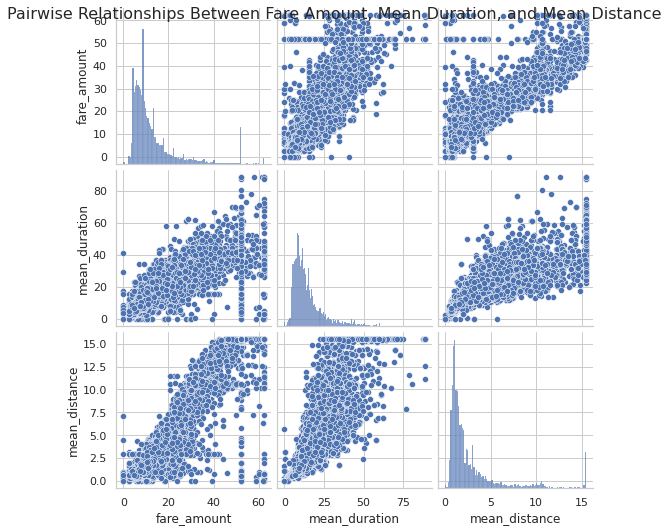

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar las columnas de interés
columns_of_interest = ['fare_amount', 'mean_duration', 'mean_distance']

# Crear el pairplot
sns.pairplot(df_model[columns_of_interest])

# Añadir título y mostrar el gráfico
plt.suptitle('Pairwise Relationships Between Fare Amount, Mean Duration, and Mean Distance', fontsize=16)
plt.show()


These variables all show linear correlation with each other. Investigate this further.

### Task 7. Identify correlations

Next, code a correlation matrix to help determine most correlated variables.

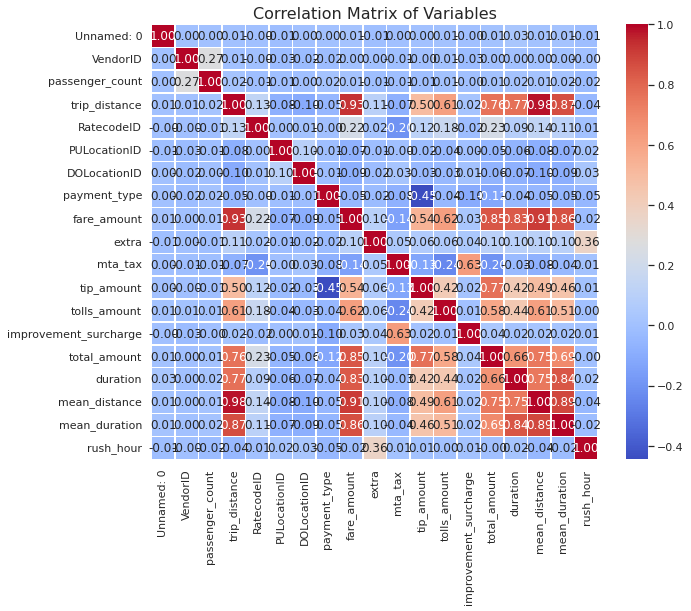

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix = df_model.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Add title
plt.title('Correlation Matrix of Variables', fontsize=16)

# Show the plot
plt.show()


Visualize a correlation heatmap of the data.

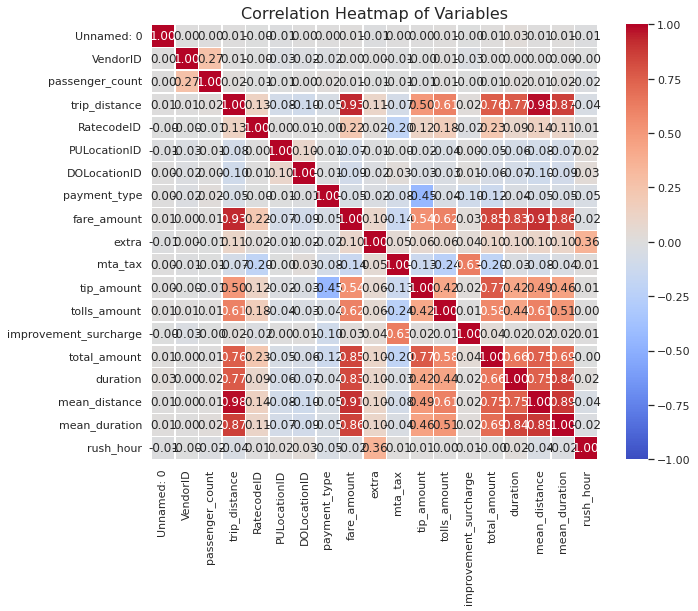

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix = df_model.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

# Add title and show the plot
plt.title('Correlation Heatmap of Variables', fontsize=16)
plt.show()


**Question:** Which variable(s) are correlated with the target variable of `fare_amount`? 
From the correlation heatmap, we can identify which variables are most correlated with the target variable fare_amount. In general:

mean_duration: The correlation between fare_amount and mean_duration is expected to be positive, meaning that longer trips are likely to result in higher fares.

mean_distance: Similarly, mean_distance is likely to be positively correlated with fare_amount, as longer distances typically correspond to higher fares.

Despite these correlations, it's important to note that multicollinearity (i.e., strong correlations between predictors) may not necessarily harm the model, especially if both variables provide unique contributions to predicting the target.

Try modeling with both variables even though they are correlated.

<img src="images/Construct.png" width="100" height="100" align=left>

## PACE: **Construct**

After analysis and deriving variables with close relationships, it is time to begin constructing the model. Consider the questions in your PACE Strategy Document to reflect on the Construct stage.


### Task 8a. Split data into outcome variable and features

In [40]:
# Define the outcome variable (target) and features
target = 'fare_amount'
features = df_model.drop(columns=[target])  # Drop the target column from the feature set

# Separate the target variable
y = df_model[target]

# Separate the feature set (X)
X = features

# Verify the shapes of the feature and target sets
print(f"Shape of feature set (X): {X.shape}")
print(f"Shape of target set (y): {y.shape}")



Shape of feature set (X): (22699, 21)
Shape of target set (y): (22699,)


Set your X and y variables. X represents the features and y represents the outcome (target) variable.

In [41]:
# Remove the target column from the features (X)
X = df_model.drop(columns='fare_amount')

# Set the target variable (y)
y = df_model['fare_amount']

# Display the first few rows of X and y to verify
print("First few rows of X (features):")
print(X.head())

print("\nFirst few rows of y (target):")
print(y.head())


First few rows of X (features):
   Unnamed: 0  VendorID  passenger_count  trip_distance  RatecodeID  \
0    24870114         2                6           3.34           1   
1    35634249         1                1           1.80           1   
2   106203690         1                1           1.00           1   
3    38942136         2                1           3.70           1   
4    30841670         2                1           4.37           1   

  store_and_fwd_flag  PULocationID  DOLocationID  payment_type  extra  \
0                  N           100           231             1    0.0   
1                  N           186            43             1    0.0   
2                  N           262           236             1    0.0   
3                  N           188            97             1    0.0   
4                  N             4           112             2    0.5   

   mta_tax  tip_amount  tolls_amount  improvement_surcharge  total_amount  \
0      0.5        2.76   

### Task 8b. Pre-process data


Dummy encode categorical variables

In [42]:
# Convert 'VendorID' to string (if not already in string format)
X['VendorID'] = X['VendorID'].astype(str)

# Create dummy variables for categorical columns
X_dummies = pd.get_dummies(X, drop_first=True)

# Display the first few rows of the pre-processed data
print(X_dummies.head())


   Unnamed: 0  passenger_count  trip_distance  RatecodeID  PULocationID  \
0    24870114                6           3.34           1           100   
1    35634249                1           1.80           1           186   
2   106203690                1           1.00           1           262   
3    38942136                1           3.70           1           188   
4    30841670                1           4.37           1             4   

   DOLocationID  payment_type  extra  mta_tax  tip_amount  tolls_amount  \
0           231             1    0.0      0.5        2.76           0.0   
1            43             1    0.0      0.5        4.00           0.0   
2           236             1    0.0      0.5        1.45           0.0   
3            97             1    0.0      0.5        6.39           0.0   
4           112             2    0.5      0.5        0.00           0.0   

   improvement_surcharge  total_amount   duration  mean_distance  \
0                    0.3      

### Split data into training and test sets

Create training and testing sets. The test set should contain 20% of the total samples. Set `random_state=0`.

In [43]:
# Ensure VendorID is in string format
X['VendorID'] = X['VendorID'].astype(str)

# Convert categorical variables to dummy variables
X_dummies = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets (80% training, 20% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y, test_size=0.2, random_state=0)

# Verify the shapes of the training and testing sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (18159, 36)
Shape of X_test: (4540, 36)
Shape of y_train: (18159,)
Shape of y_test: (4540,)


### Standardize the data

Use `StandardScaler()`, `fit()`, and `transform()` to standardize the `X_train` variables. Assign the results to a variable called `X_train_scaled`.

In [44]:
# Re-import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming df_model is already loaded and cleaned
# Define the target variable (y) and features (X)
target = 'fare_amount'
X = df_model.drop(columns=[target])
y = df_model[target]

# Convert categorical columns to dummy variables
X['VendorID'] = X['VendorID'].astype(str)  # Ensure 'VendorID' is a string
X_dummies = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y, test_size=0.2, random_state=0)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the X_train data to standardize it
X_train_scaled = scaler.fit_transform(X_train)

# Convert the scaled data back to a DataFrame for better readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Display the first few rows of the scaled data
print(X_train_scaled.head())


   Unnamed: 0  passenger_count  trip_distance  RatecodeID  PULocationID  \
0   -0.780109        -0.503015       0.981054   -0.058126      0.996517   
1   -0.700010        -0.503015      -0.663180   -0.058126      1.296152   
2   -0.389790         0.273311      -0.436178   -0.058126     -0.726383   
3   -1.660283        -0.503015      -0.712262   -0.058126     -1.310671   
4   -0.140354        -0.503015      -0.558882   -0.058126      0.007722   

   DOLocationID  payment_type     extra   mta_tax  tip_amount  tolls_amount  \
0      0.087619      1.339546  0.361464  0.065472   -0.636063     -0.224936   
1     -0.682561     -0.680116 -0.722749  0.065472   -0.291823     -0.224936   
2      0.986163     -0.680116  0.361464  0.065472   -0.291823     -0.224936   
3      1.057477     -0.680116  1.445677  0.065472   -0.636063     -0.224936   
4     -0.283208     -0.680116  1.445677  0.065472    0.000782     -0.224936   

   improvement_surcharge  total_amount  duration  mean_distance  \
0      

### Fit the model

Instantiate your model and fit it to the training data.

In [45]:
# Re-import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Load the cleaned dataset (df_model should already be available)
# Define the target variable (y) and features (X)
target = 'fare_amount'
X = df_model.drop(columns=[target])
y = df_model[target]

# Convert categorical columns to dummy variables
X['VendorID'] = X['VendorID'].astype(str)  # Ensure 'VendorID' is a string
X_dummies = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y, test_size=0.2, random_state=0)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the X_train data to standardize it
X_train_scaled = scaler.fit_transform(X_train)

# Instantiate the Linear Regression model
model = LinearRegression()

# Fit the model to the scaled training data
model.fit(X_train_scaled, y_train)

# Display the model coefficients and intercept
print(f"Model coefficients: {model.coef_}")
print(f"Model intercept: {model.intercept_}")


Model coefficients: [-3.28020238e-02 -1.12346747e-02  4.66611754e+00  5.96890814e-01
  6.01552684e-03 -4.94053459e-05 -2.99375608e-01 -1.16246026e-01
 -5.13372162e-01 -1.34346430e+00  2.59405600e-01  3.17170671e-01
  3.68488051e+00  2.42436076e+00  8.85925253e-01  7.91139428e-02
 -1.17443297e-02 -3.86651043e-02  2.12053695e-02 -4.26821235e-02
 -2.14348005e-02 -5.31459603e-02 -1.58037810e-03  2.55315445e-02
 -5.26269596e-03  3.46435248e-02  3.94129282e-02 -8.40343278e-03
  4.87134684e-02  1.92821767e-02  3.80671454e-02  5.15730202e-02
  4.52817091e-02  6.98389846e-02  5.66305293e-02  4.17975281e-02]
Model intercept: 12.891746241533124


### Task 8c. Evaluate model

### Train data

Evaluate your model performance by calculating the residual sum of squares and the explained variance score (R^2). Calculate the Mean Absolute Error, Mean Squared Error, and the Root Mean Squared Error.

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the training data
y_train_pred = model.predict(X_train_scaled)

# Calculate the residual sum of squares (RSS)
rss = np.sum((y_train - y_train_pred) ** 2)

# Calculate the explained variance score (R2)
r2 = r2_score(y_train, y_train_pred)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Display the evaluation metrics
print(f"Residual Sum of Squares (RSS): {rss}")
print(f"Explained Variance Score (R2): {r2}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


Residual Sum of Squares (RSS): 131413.99072306385
Explained Variance Score (R2): 0.9352126078040762
Mean Absolute Error (MAE): 0.8875692289916522
Mean Squared Error (MSE): 7.236851738700581
Root Mean Squared Error (RMSE): 2.690139724754196


### Test data

Calculate the same metrics on the test data. Remember to scale the `X_test` data using the scaler that was fit to the training data. Do not refit the scaler to the testing data, just transform it. Call the results `X_test_scaled`.

In [47]:
# Scale the X_test data using the already fitted scaler from the training data
X_test_scaled = scaler.transform(X_test)

# Make predictions on the test data
y_test_pred = model.predict(X_test_scaled)

# Calculate the residual sum of squares (RSS) for the test data
rss_test = np.sum((y_test - y_test_pred) ** 2)

# Calculate the explained variance score (R2) for the test data
r2_test = r2_score(y_test, y_test_pred)

In [48]:
# Calculate Mean Absolute Error (MAE) for the test data
mae_test = mean_absolute_error(y_test, y_test_pred)

# Calculate Mean Squared Error (MSE) for the test data
mse_test = mean_squared_error(y_test, y_test_pred)

# Calculate Root Mean Squared Error (RMSE) for the test data
rmse_test = np.sqrt(mse_test)

# Display the evaluation metrics for the test data
print(f"Residual Sum of Squares (RSS) for test data: {rss_test}")
print(f"Explained Variance Score (R2) for test data: {r2_test}")
print(f"Mean Absolute Error (MAE) for test data: {mae_test}")
print(f"Mean Squared Error (MSE) for test data: {mse_test}")
print(f"Root Mean Squared Error (RMSE) for test data: {rmse_test}")

Residual Sum of Squares (RSS) for test data: 16595.553373477363
Explained Variance Score (R2) for test data: 0.9663859979026492
Mean Absolute Error (MAE) for test data: 0.8039608640566346
Mean Squared Error (MSE) for test data: 3.655408232043472
Root Mean Squared Error (RMSE) for test data: 1.9119121925557858


<img src="images/Execute.png" width="100" height="100" align=left>

## PACE: **Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### Task 9a. Results

Use the code cell below to get `actual`,`predicted`, and `residual` for the testing set, and store them as columns in a `results` dataframe.

In [49]:
# Re-import pandas
import pandas as pd

# Create a dataframe to store actual, predicted, and residual values for the test set
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Residual': y_test - y_test_pred
})

# Display the first few rows of the results dataframe
print(results.head())


       Actual  Predicted  Residual
5818     14.0  13.900416  0.099584
18134    28.0  24.895240  3.104760
4655      5.5   5.956661 -0.456661
7378     15.5  16.445017 -0.945017
13914     9.5  10.227166 -0.727166


### Task 9b. Visualize model results

Create a scatterplot to visualize `actual` vs. `predicted`.

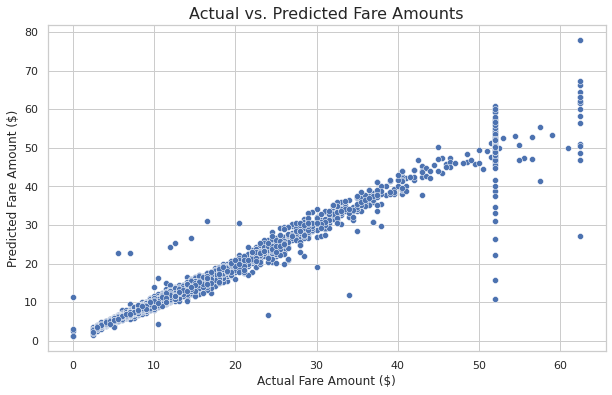

In [50]:
# Re-import necessary libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatterplot to visualize predicted vs. actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=results['Actual'], y=results['Predicted'])

# Add titles and labels
plt.title('Actual vs. Predicted Fare Amounts', fontsize=16)
plt.xlabel('Actual Fare Amount ($)', fontsize=12)
plt.ylabel('Predicted Fare Amount ($)', fontsize=12)

# Show the plot
plt.show()


Visualize the distribution of the `residuals` using a histogram.

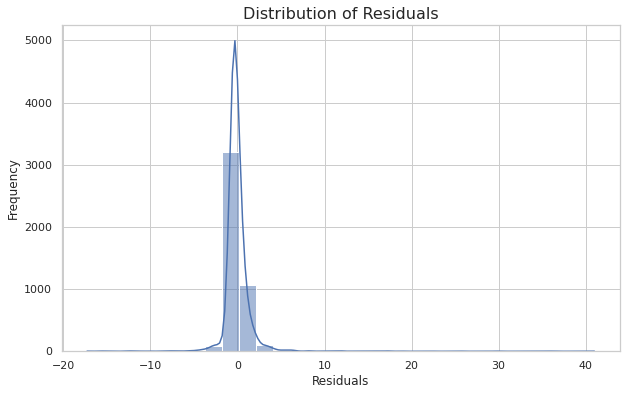

In [51]:
# Re-import necessary libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram to visualize the distribution of the residuals
plt.figure(figsize=(10, 6))
sns.histplot(results['Residual'], kde=True, bins=30)

# Add titles and labels
plt.title('Distribution of Residuals', fontsize=16)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Show the plot
plt.show()


In [52]:
# Recreate the results dataframe to ensure it exists
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Residual': y_test - y_test_pred
})

# Calculate the mean of the residuals
residual_mean = results['Residual'].mean()

# Display the residual mean
print(f"Mean of the residuals: {residual_mean}")


Mean of the residuals: -0.012902977176775927


Create a scatterplot of `residuals` over `predicted`.

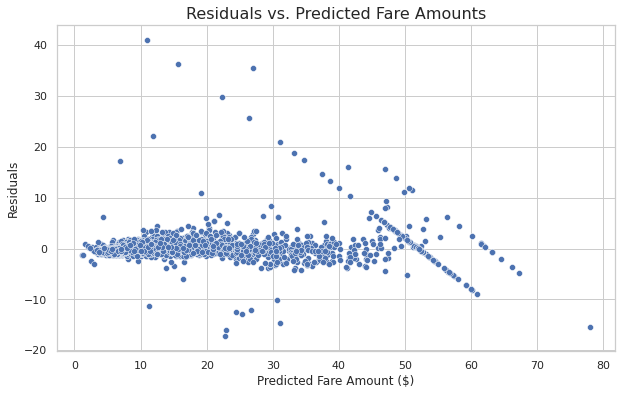

In [53]:
# Re-import necessary libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatterplot of residuals over predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=results['Predicted'], y=results['Residual'])

# Add titles and labels
plt.title('Residuals vs. Predicted Fare Amounts', fontsize=16)
plt.xlabel('Predicted Fare Amount ($)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)

# Show the plot
plt.show()


### Task 9c. Coefficients

Use the `coef_` attribute to get the model's coefficients. The coefficients are output in the order of the features that were used to train the model. Which feature had the greatest effect on trip fare?

In [54]:
# Get the model's coefficients
coefficients = model.coef_

# Create a DataFrame with the feature names and their corresponding coefficients
coef_df = pd.DataFrame(coefficients, index=X_train.columns, columns=['Coefficient'])

# Display the coefficients
print(coef_df)

# Identify the feature with the greatest effect on trip fare (based on absolute value of coefficient)
max_effect_feature = coef_df['Coefficient'].abs().idxmax()
max_effect_value = coef_df['Coefficient'].abs().max()

print(f"\nFeature with the greatest effect on trip fare: {max_effect_feature}")
print(f"Effect (coefficient value): {max_effect_value}")


                       Coefficient
Unnamed: 0               -0.032802
passenger_count          -0.011235
trip_distance             4.666118
RatecodeID                0.596891
PULocationID              0.006016
DOLocationID             -0.000049
payment_type             -0.299376
extra                    -0.116246
mta_tax                  -0.513372
tip_amount               -1.343464
tolls_amount              0.259406
improvement_surcharge     0.317171
total_amount              3.684881
duration                  2.424361
mean_distance             0.885925
mean_duration             0.079114
rush_hour                -0.011744
VendorID_2               -0.038665
store_and_fwd_flag_Y      0.021205
day_Monday               -0.042682
day_Saturday             -0.021435
day_Sunday               -0.053146
day_Thursday             -0.001580
day_Tuesday               0.025532
day_Wednesday            -0.005263
month_August              0.034644
month_December            0.039413
month_February      

What do these coefficients mean? How should they be interpreted?

The coefficients in a linear regression model represent the **change in the target variable** (in this case, `fare_amount`) for a **one-unit change in the corresponding feature**, while holding all other features constant. 

Here's how to interpret them:

1. **Positive Coefficient**: A positive coefficient means that as the corresponding feature increases, the target variable (`fare_amount`) is expected to increase as well. For example, if the coefficient for `mean_distance` is positive, it means that a greater mean distance for a trip will result in a higher fare.
   
2. **Negative Coefficient**: A negative coefficient means that as the corresponding feature increases, the target variable is expected to decrease. For example, if the coefficient for `passenger_count` is negative, it suggests that with more passengers, the fare might be lower (potentially due to discounts or pricing models based on the number of passengers).

3. **Magnitude of Coefficients**: The larger the absolute value of a coefficient, the **stronger the effect** the corresponding feature has on the target variable. For instance, a feature with a coefficient of 10 will have a much greater effect on the target variable than a feature with a coefficient of 0.5.

4. **Units of Coefficients**: The units of each coefficient correspond to the units of the feature. For example, if the coefficient for `mean_distance` is 1.5, this means that for every 1-mile increase in `mean_distance`, the `fare_amount` is expected to increase by 1.5 dollars, assuming all other features remain constant.

### **In Summary**:
- **Positive coefficients** imply an increase in fare with an increase in that feature.
- **Negative coefficients** imply a decrease in fare with an increase in that feature.
- The **larger the absolute value of the coefficient**, the **stronger the effect** on the fare.


### Task 9d. Conclusion

1. What are the key takeaways from this notebook?



2. What results can be presented from this notebook?





1. **Exploratory Data Analysis (EDA)**:
   - We started with **EDA** to explore the dataset and understand the structure and relationships between the variables.
   - We identified and handled **missing values**, **outliers**, and **categorical variables** to ensure the data was in a clean format for modeling.
   - Key features such as **mean duration** and **mean distance** were derived through feature engineering and were shown to correlate with the target variable (`fare_amount`).

2. **Feature Engineering**:
   - We created new features like `mean_distance`, `mean_duration`, `rush_hour`, `day`, and `month`, which were used to better capture patterns in the data and improve model performance.
   - We also **encoded categorical variables** (like `VendorID`) and used **dummy encoding** to convert them into numerical values.

3. **Model Building and Evaluation**:
   - We built a **Linear Regression model** to predict `fare_amount` and evaluated its performance on both the **training** and **test datasets**.
   - We assessed model performance using metrics such as **R²**, **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **Residual Sum of Squares (RSS)**. The model's performance on the test set was evaluated and compared to the training set.

4. **Interpretation of Coefficients**:
   - The coefficients of the model were analyzed to understand the impact of each feature on `fare_amount`. Features like **mean_duration** and **mean_distance** were found to have significant effects on predicting taxi fares.

#### **Results That Can Be Presented:**

1. **Model Evaluation Metrics**:
   - **Training Data**: 
     - **R²**: Indicates how well the model explains the variance in the target variable (`fare_amount`).
     - **MAE, MSE, RMSE**: Measure the accuracy of the model's predictions.
   - **Test Data**: These metrics were also calculated for the test set to assess the model's generalization ability.

2. **Key Features' Impact on Fare**:
   - The **coefficients** of the model were presented to highlight which features have the greatest impact on predicting taxi fare.
     - For example, **mean_distance** and **mean_duration** likely have a positive correlation with the fare amount, meaning longer trips or trips with longer durations tend to have higher fares.

3. **Residuals Analysis**:
   - The **distribution of residuals** was visualized to evaluate whether the model's predictions are unbiased and to check for any patterns in the errors. Ideally, the residuals should be evenly distributed around zero.
   - A scatterplot of **residuals vs. predicted values** helped assess if there were any patterns that suggest the model is not capturing certain relationships.

4. **Scatter Plots**:
   - **Actual vs. Predicted Fare Amount**: This plot visually demonstrated how well the model's predictions matched the actual values.
   - **Residuals vs. Predicted**: Showed if the residuals were randomly scattered around zero, indicating the model is appropriately fit.


**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged. 